In [1]:
# Example loading and plotting lidar data of Hybrid Dune Campaign

import numpy as np 
import xarray as xr
import os   
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib as mpl
from scipy.ndimage import gaussian_filter1d
from scipy.signal import savgol_filter
from netCDF4 import Dataset
import warnings

import sys
sys.path.append('../functions')
from convert_lidar_coordinates_ds_single import convert_lidar_coordinates_ds


In [6]:
## 0) FUNCTION TO COMPUTE PERCENTILES UNAFFECTED BY NaNs
def percentile_nans_lowest(data, percentile, *, axis=None, method="linear"):
    """
    Compute percentiles treating NaNs as the lowest-ranked values, preserving array size and never returning -inf.
    So given 10 minutes of data, the 90th percentile is exceeded for 1 minute, irrespective of the number of nans.

    Parameters
    ----------
    data : array_like. Input data.
    percentile : float or array_like. Percentile(s) in [0, 100].
    axis : int or tuple of int, optional. Axis or axes along which the percentiles are computed. Default is None (flattened array).
    method : str, optional. Quantile interpolation method (passed to np.quantile).

    Returns
    -------
    percentile_values : ndarray
        Percentile values. Positions corresponding to NaN-only percentiles return np.nan.
    """
    data = np.asarray(data)
    p = np.asarray(percentile) / 100.0                          # convert to quantiles

    # Count NaNs along the axis
    nan_count = np.sum(np.isnan(data), axis=axis, keepdims=True)
    total_count = np.size(data, axis=axis)

    # All-NaN slices → return NaN
    if axis is None:
        if nan_count == total_count:
            return np.nan
    else:
        all_nan_mask = (nan_count == total_count)

    filled = np.nan_to_num(data, nan=-np.inf)                    # Replace NaNs with -inf for ranking only
    result = np.quantile(filled, p, axis=axis, method=method)    # Compute quantiles
    result = np.where(np.isneginf(result), np.nan, result)       # Replace -inf outputs with NaN

    # Handle all-NaN slices (for axis case)
    if axis is not None:
        result = np.where(all_nan_mask.squeeze(axis), np.nan, result)

    return result

In [193]:
# Load lidar volume data
folder = "C:\\Users\\dpoppema\\Documents\\lidar_processing"
filename = f"ds_profiles_corrected_lidar2_storm1.nc"
ds1a = xr.open_dataset(os.path.join(folder, filename))

folder = "C:\\Users\\dpoppema\\Documents\\lidar_processing"
filename = f"ds_profiles_corrected_lidar2_storm2.nc"
ds2a = xr.open_dataset(os.path.join(folder, filename))

folder = "C:\\Users\\dpoppema\\Documents\\lidar_processing"
filename = f"ds_profiles_corrected_lidar2_storm3.nc"
ds3a = xr.open_dataset(os.path.join(folder, filename))

In [194]:
# Add hydrodynamic data from RBR netcdf file --------------------------------------------------------
n_lidar=2
for n_storm in [1, 2, 3]:
    # Select lidar dataset  -----------------------------------------------------------------------
    if n_storm == 1:
        ds_plot = ds1a.copy()
        t1 = pd.Timestamp('19-12-2024 00:02') # was 2:00
        t2 = pd.Timestamp('19-12-2024 22:00') # was 19dec 22:00
    elif n_storm == 2:
        ds_plot = ds2a.copy()
        t1 = pd.Timestamp('22-12-2024 04:00')
        t2 = pd.Timestamp('22-12-2024 23:10')
    elif n_storm == 3:
        ds_plot = ds3a.copy()
        t1 = np.datetime64('2025-01-01T12:00')
        t2 = np.datetime64('2025-01-02T09:09')  # ensure that Jan 2 is selected, not Feb 1
    else:
        raise ValueError('n_storm must be 1, 2, or 3')

    # Load pressure sensor data -----------------------------------------------------------------------
    if n_storm <= 2:
        #nc_rbr = r'O:\HybridDune experiment\data RBR, OSSI\netcdf\processed\Deployment period 1\Pressure sensor S3P3 RBR6 processed data - period 1.nc'
        nc_P = r'C:\Users\dpoppema\OneDrive - Delft University of Technology\dataset_hybrid_dune\Hydrodynamics\Pressure sensors beach and shoreface (BS)\processed\Deployment period 1\Pressure sensor S3 P_BS3 (RBR) processed data - period 1.nc'
        nc_P = r'C:\Users\dpoppema\OneDrive - Delft University of Technology\dataset_hybrid_dune\Hydrodynamics\Pressure sensors beach and shoreface (BS)\processed\Deployment period 1\Pressure sensor S2 P_BS1 (Ossi) processed data - period 1.nc'
    else:
        #nc_rbr = r'O:\HybridDune experiment\data RBR, OSSI\netcdf\processed\Deployment period 2\Pressure sensor S3P3 RBR6 processed data - period 2.nc'
        nc_P = r'C:\Users\dpoppema\OneDrive - Delft University of Technology\dataset_hybrid_dune\Hydrodynamics\Pressure sensors beach and shoreface (BS)\processed\Deployment period 2\Pressure sensor S3 P_BS3 (RBR) processed data - period 2.nc'
        nc_P = r'C:\Users\dpoppema\OneDrive - Delft University of Technology\dataset_hybrid_dune\Hydrodynamics\Pressure sensors beach and shoreface (BS)\processed\Deployment period 2\Pressure sensor S3 P_BS1 (RBR) processed data - period 2.nc'

    ds_P = xr.open_dataset(nc_P)

    ds_P_sel = ds_P.sel(t_block=slice(t1, t2), t_full=slice(t1, t2)) # ensure that both t_block and t_full are sliced to avoid issues with time steps
    ds_P_sel['t_block'] = pd.to_datetime(ds_P_sel.t_block.values).round('60s')
    # # compare the time steps in both datasets
    # # Round time values to the nearest 10s to avoid floating point issues
    # t_round = pd.to_datetime(ds_plot.t.values).round('10s')
    # t_round2 = pd.to_datetime(ds_P_sel.t_block.values).round('10s')
    # if ~(t_round == t_round2).all():
    #     # give error
    #     raise ValueError('Time steps in P:BS and Lidar datasets do not match.')


    # Add wave statistics from pressure sensor to dataset ---------------------------------------------------------
    ds_plot['zs_mean'] = ds_P_sel.zs_mean
    ds_plot['Hm0'] = ds_P_sel.Hm0
    ds_plot['Tp'] = ds_P_sel.Tps # Tps: smoothed Tp
    ds_plot['Tm01'] = ds_P_sel.Tm01 # Tm01: mean wave period

    #Calculate stockdon wave runup using wave statistics ---------------------------------------------------------
    beta = 0.04  # beach slope, set as needed
    L = (9.81 * ds_plot.Tp**2) / (2 * np.pi)  # deep water wavelength, assuming Tp S3P3 is deep water
    ksi = beta / np.sqrt(ds_plot.Hm0 / L) # irrabaren number
    eta_u = 0.35 * ds_plot.Hm0 * ksi # wave setup
    Sw    = 0.75 * ds_plot.Hm0 * ksi # runup wind waves
    Sig   = 0.06* (ds_plot.Hm0 * L)**0.5  # runup IG waves

    r2procent_A = (1.1 * (eta_u + Sw) + 1.7 * Sig)
    r2procent_B = 0.043 * (ds_plot.Hm0 * L)**0.5

    # r_A is ksi>=0.3, r_B is ksi<0.3
    # r2procent = xr.where(ksi >= 0.3, r2procent_A, r2procent_B)  # skip: huge effect from ksi just above or below 0.3
    r2procent = r2procent_A
    
    ds_plot['ksi'] = ksi
    ds_plot['ksi'].attrs = {'long_name': 'Iribarren number', 'units': '-'}

    ds_plot['r2procent'] =r2procent
    ds_plot['r2procent'].attrs = {'long_name': '2% runup', 'units': 'm above still water level'}

    ds_plot['r2procent_NAP'] = ds_plot.r2procent + ds_plot.zs_mean
    ds_plot['r2procent_NAP'].attrs = {'long_name': '2% runup height in NAP', 'units': 'm NAP'}

    # Calculate zs_98%, the water level that is exceeded for 2% of the time ---------------------------------------------------------
    # Calculate per 20-minute block. Follow convention of ds_P_sel, which has a time coordinate t_block that corresponds to the start of each block
    zs = ds_P_sel.zs.values
    sf_P = float(ds_P_sel.sf.values)  # sampling frequency in Hz
    window_samples = int(20 * 60 * sf_P)  # number of samples in 20 minutes
    t_block = pd.to_datetime(ds_P_sel.t_block.values)

    # Number of full non-overlapping 20-minute blocks
    n_windows = len(zs) // window_samples
    zs98_list = []
    t_starts = []
    for i in range(n_windows):
        s = i * window_samples
        e = s + window_samples
        block = zs[s:e]
        zs98_list.append(percentile_nans_lowest(block, 98))
        t_starts.append(t_block[i])

    # Create an xarray DataArray with the start time of each block as coordinate
    zs_98_da = xr.DataArray(
        np.array(zs98_list),
        coords={'t_block': ('t_block', t_starts)},
        dims=['t_block']
    )
    zs_98_da.attrs = {
        'long_name': '98th percentile of zs per 20-min block',
        'units': ds_P_sel.zs.attrs.get('units', 'm')
    }

    ds_plot['zs_98'] = zs_98_da

    # Calculate the dune erosion per block -----------------------------------------------------------------------------------
    # Use ds_P_sel.t_block as the start times of 20-min blocks
    t_block = pd.to_datetime(ds_P_sel.t_block.values)

    dune_da = ds_plot['dune_area']

    # Build a pandas Series indexed by the dune time coordinate for easy reindexing
    dune_index = pd.to_datetime(dune_da['minute'].values)
    dune_series = pd.Series(dune_da.values, index=dune_index)

    # Get dune area at block start and 20 minutes later (nearest match). Missing values remain NaN
    dune_start = dune_series.reindex(t_block, method='nearest')
    dune_plus = dune_series.reindex(t_block + pd.Timedelta(minutes=20), method='nearest')
    dune_erosion_vals = dune_start.values - dune_plus.values

    # Create DataArray with t_block as coordinate
    dune_erosion_da = xr.DataArray(
        dune_erosion_vals,
        coords={'t_block': ('t_block', t_block)},
        dims=['t_block'] )
    
    dune_erosion_da.attrs = {
        'long_name': 'dune erosion over 20 min (dune_area(start) - dune_area(start+20min))',
        'units': ds_plot.dune_area.attrs.get('units', '')     }
    
    # Assign into ds_plot
    ds_plot['dune_erosion'] = dune_erosion_da

    # compute right-aligned rolling mean then shift left by window-1 to assign the value to the window start ----------------------------------------
    window_samples = 20  # 20 minute window, 1-minute data
    z_toe_roll = ds_plot.z_toe.rolling({'minute': window_samples}, min_periods=1, center=False).mean()

    t_block_possible = ds_plot.t_block.sel(t_block=slice(z_toe_roll.minute[0], z_toe_roll.minute[-1])) # only consider t_block times that are within the range of z_toe_roll
    z_toe_smooth = z_toe_roll.shift({'minute': -(window_samples - 1)}).sel(minute=t_block_possible) # select only the times corresponding to t_block, which are the times of interest for the erosion calculation

    # store result of z_toe_smooth in ds_plot, only for times t_block and with coordinate t_block
    ds_plot['z_toe_smooth'] = xr.DataArray(  z_toe_smooth.values,
                                            coords={'t_block': ('t_block', z_toe_smooth.minute.values)},
                                            dims=['t_block'] )
    
    # Assign back to storm datasets --------------------------------------------
    if n_storm == 1:
        ds1a=ds_plot.copy()
    elif n_storm == 2:
        ds2a=ds_plot.copy()
    elif n_storm == 3:
        ds3a=ds_plot.copy()

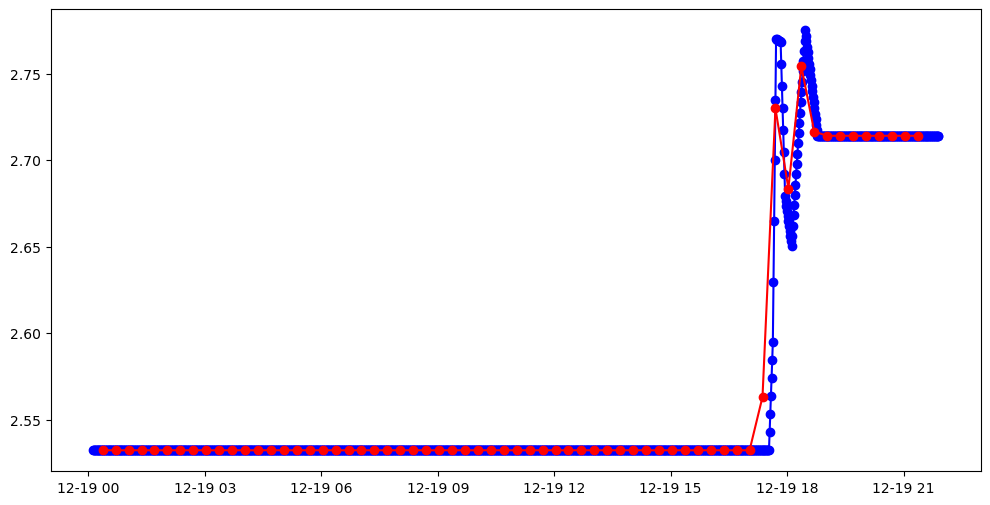

In [175]:
ds_plot = ds1a.copy()

# Plot toe elevation
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(ds_plot.minute, ds_plot.z_toe, '-o',label='original z_toe', color='blue')
ax.plot(ds_plot.t_block, ds_plot.z_toe_smooth, '-o',label='smoothed z_toe', color='red')

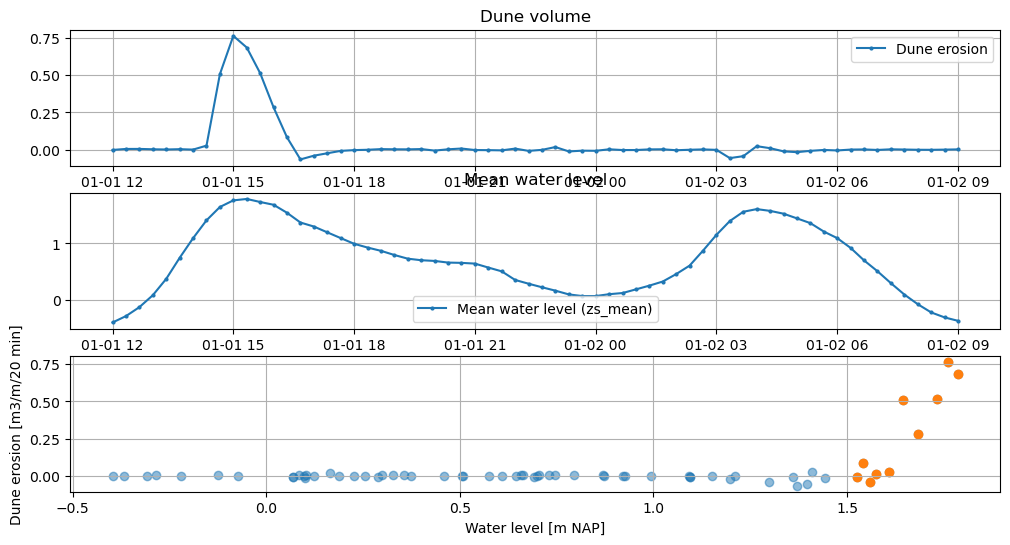

In [190]:
# Plot result
t = ds_plot.t_block

# plot t vs zs_mean and t vs dune_erosion
fig, axs = plt.subplots(3,1, figsize=(12, 6))

ax = axs[0]
#ax.plot(ds_plot.minute, ds_plot.dune_area, '-o', markersize=2, label='Dune volume')
ax.plot(ds_plot.t_block, ds_plot.dune_erosion, '-o', markersize=2, label='Dune erosion')

ax.grid()
ax.set_title('Dune volume')
ax.legend()

ax = axs[1]
ax.plot(ds_plot.t_block, ds_plot.zs_mean, '-o', markersize=2, label='Mean water level (zs_mean)')
ax.grid()
ax.set_title('Mean water level')
ax.legend()

ax = axs[2]
ax.scatter(ds_plot.zs_mean, ds_plot.dune_erosion, alpha=0.5, label='Dune erosion vs mean water level')
ax.scatter(ds_plot.zs_mean.where(ds_plot.zs_mean>1.5), ds_plot.dune_erosion, label='Dune erosion vs mean water level')

ax.set_xlabel('Water level [m NAP]')
ax.set_ylabel('Dune erosion [m3/m/20 min]')
ax.grid()

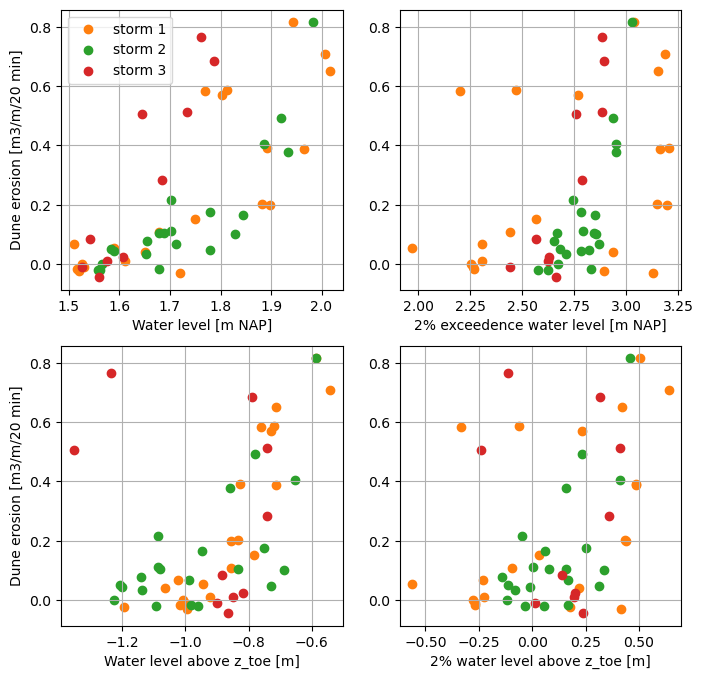

In [191]:
# Plot result
z_min = 1.5 # plot only blocks with a mean water level abovez_min

# plot t vs zs_mean and t vs dune_erosion
fig, axs = plt.subplots(2,2, figsize=(8, 8))

for n_storm in [1, 2, 3]:
    # Select lidar dataset  -----------------------------------------------------------------------
    if n_storm == 1:
        ds_plot = ds1a.copy()
    elif n_storm == 2:
        ds_plot = ds2a.copy()
    elif n_storm == 3:
        ds_plot = ds3a.copy()

    color = mpl.colormaps['tab10'](n_storm)

    # Water level
    ax = axs[0,0]
    ax.scatter(ds_plot.zs_mean.where(ds_plot.zs_mean>z_min), ds_plot.dune_erosion, label=f'storm {n_storm}', color=color)

    ax.set_xlabel('Water level [m NAP]')
    ax.set_ylabel('Dune erosion [m3/m/20 min]')
    ax.legend()
    ax.grid()

    # 2% Exceedence water level
    ax = axs[0,1]
    ax.scatter(ds_plot.zs_98.where(ds_plot.zs_mean>z_min), ds_plot.dune_erosion, label=f'storm {n_storm}', color=color)

    ax.set_xlabel("2% exceedence water level [m NAP]")
    #ax.set_ylabel('Dune erosion [m3/m/20 min]')
    ax.grid()

    #Water level above toe
    ax = axs[1,0]
    ax.scatter(ds_plot.zs_mean - ds_plot.z_toe_smooth, ds_plot.dune_erosion.where(ds_plot.zs_mean>z_min), label=f'storm {n_storm}', color=color)

    ax.set_xlabel('Water level above z_toe [m]')
    ax.set_ylabel('Dune erosion [m3/m/20 min]')
    ax.grid()

    # 2% level above toe
    ax = axs[1,1]
    ax.scatter(ds_plot.zs_98 - ds_plot.z_toe_smooth, ds_plot.dune_erosion.where(ds_plot.zs_mean>z_min), label=f'storm {n_storm}', color=color)

    ax.set_xlabel("2% water level above z_toe [m]")
    #ax.set_ylabel('Dune erosion [m3/m/20 min]')
    ax.grid()

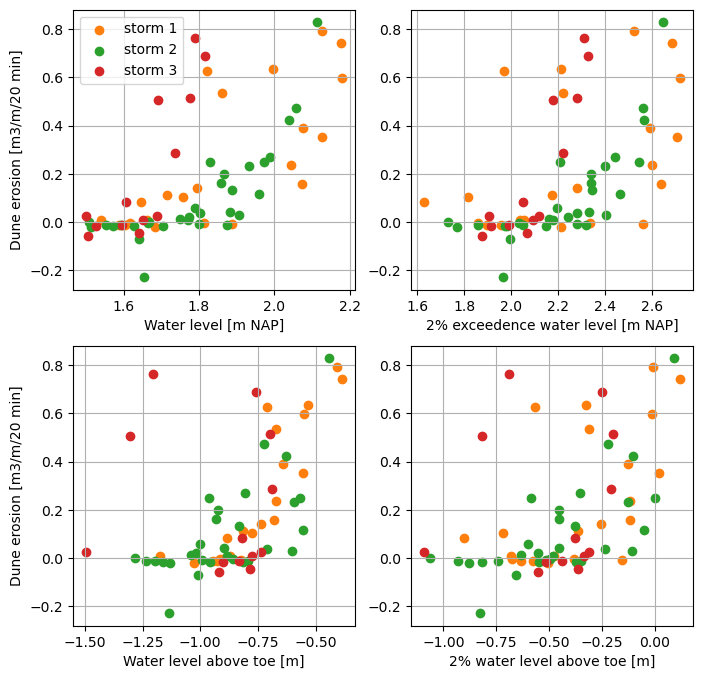

In [187]:
# Plot result
z_min = 1.5 # plot only blocks with a mean water level abovez_min

# plot t vs zs_mean and t vs dune_erosion
fig, axs = plt.subplots(2,2, figsize=(8, 8))

for n_storm in [1, 2, 3]:
    # Select lidar dataset  -----------------------------------------------------------------------
    if n_storm == 1:
        ds_plot = ds1a.copy()
    elif n_storm == 2:
        ds_plot = ds2a.copy()
    elif n_storm == 3:
        ds_plot = ds3a.copy()

    color = mpl.colormaps['tab10'](n_storm)

    # Water level
    ax = axs[0,0]
    ax.scatter(ds_plot.zs_mean.where(ds_plot.zs_mean>z_min), ds_plot.dune_erosion, label=f'storm {n_storm}', color=color)

    ax.set_xlabel('Water level [m NAP]')
    ax.set_ylabel('Dune erosion [m3/m/20 min]')
    ax.legend()
    ax.grid()

    # 2% Exceedence water level
    ax = axs[0,1]
    ax.scatter(ds_plot.zs_98.where(ds_plot.zs_mean>z_min), ds_plot.dune_erosion, label=f'storm {n_storm}', color=color)

    ax.set_xlabel("2% exceedence water level [m NAP]")
    #ax.set_ylabel('Dune erosion [m3/m/20 min]')
    ax.grid()

    #Water level above toe
    ax = axs[1,0]
    ax.scatter(ds_plot.zs_mean - ds_plot.z_toe_smooth, ds_plot.dune_erosion.where(ds_plot.zs_mean>z_min), label=f'storm {n_storm}', color=color)

    ax.set_xlabel('Water level above toe [m]')
    ax.set_ylabel('Dune erosion [m3/m/20 min]')
    ax.grid()

    # 2% level above toe
    ax = axs[1,1]
    ax.scatter(ds_plot.zs_98 - ds_plot.z_toe_smooth, ds_plot.dune_erosion.where(ds_plot.zs_mean>z_min), label=f'storm {n_storm}', color=color)

    ax.set_xlabel("2% water level above toe [m]")
    #ax.set_ylabel('Dune erosion [m3/m/20 min]')
    ax.grid()

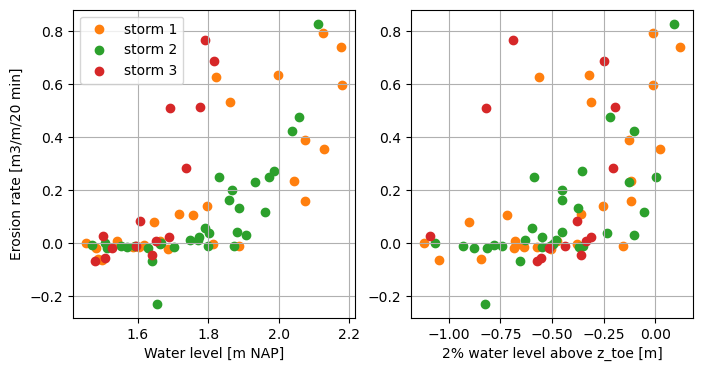

In [198]:
# Plot result
z_min = 1.45 # plot only blocks with a mean water level abovez_min

# plot t vs zs_mean and t vs dune_erosion
fig, axs = plt.subplots(1,2, figsize=(8, 4))

for n_storm in [1, 2, 3]:
    # Select lidar dataset  -----------------------------------------------------------------------
    if n_storm == 1:
        ds_plot = ds1a.copy()
    elif n_storm == 2:
        ds_plot = ds2a.copy()
    elif n_storm == 3:
        ds_plot = ds3a.copy()

    color = mpl.colormaps['tab10'](n_storm)

    # Water level
    ax = axs[0]
    ax.scatter(ds_plot.zs_mean.where(ds_plot.zs_mean>z_min), ds_plot.dune_erosion, label=f'storm {n_storm}', color=color)

    ax.set_xlabel('Water level [m NAP]')
    ax.set_ylabel('Erosion rate [m3/m/20 min]')
    ax.legend()
    ax.grid()

    # 2% level above toe
    ax = axs[1]
    ax.scatter(ds_plot.zs_98 - ds_plot.z_toe_smooth, ds_plot.dune_erosion.where(ds_plot.zs_mean>z_min), label=f'storm {n_storm}', color=color)

    ax.set_xlabel("2% water level above z_toe [m]")
    
    #ax.set_ylabel('Dune erosion [m3/m/20 min]')
    ax.grid()